# Log Analysis
This notebook parses the log files to visualize the validation loss against iterations and time. It also extracts key statistics like peak memory, total training time, and step average.

Found 5 log file(s)

--- 283a8757-5768-460e-930a-b67ab2894c51.txt ---
Total Training Time: 268.15s
Final Step Average:  179.97ms
Peak Memory:         peak memory allocated: 31651 MiB reserved: 48382 MiB



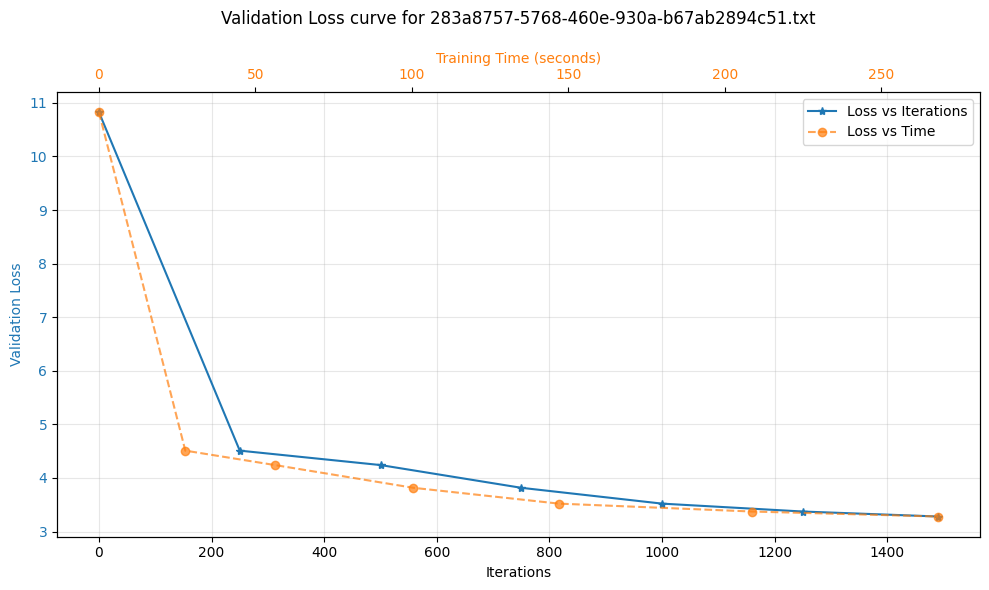

--- d261adeb-653e-4f3c-9a63-4c9ef58c7417.txt ---
Total Training Time: 268.17s
Final Step Average:  179.98ms
Peak Memory:         peak memory allocated: 31651 MiB reserved: 48382 MiB



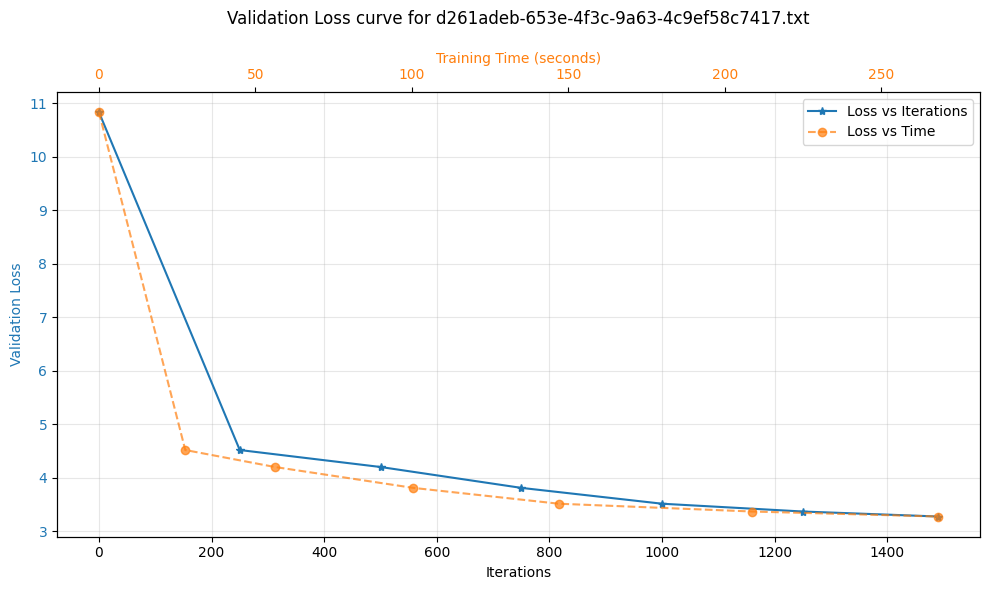

--- 137602ee-f9b0-49f0-bb1f-578e9ee9a81a.txt ---
Total Training Time: 269.14s
Final Step Average:  180.63ms
Peak Memory:         peak memory allocated: 31651 MiB reserved: 48382 MiB



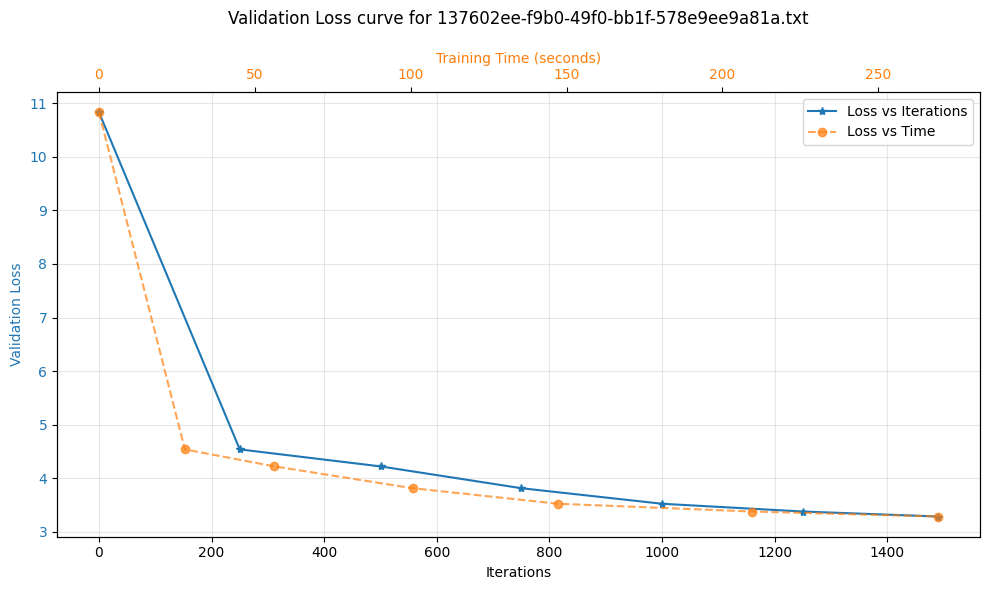

--- 9bc357af-84e0-410e-aec1-456ebc2a8e2a.txt ---
Total Training Time: 269.39s
Final Step Average:  180.80ms
Peak Memory:         peak memory allocated: 31651 MiB reserved: 48382 MiB



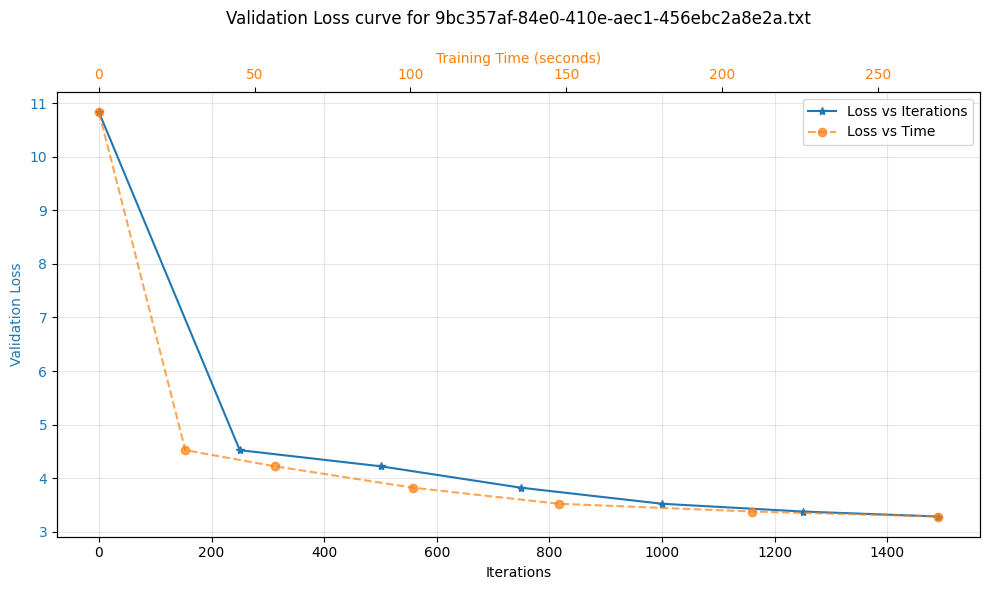

--- 2c31e830-dd3a-425a-b314-580a9bc05d5f.txt ---
Total Training Time: 269.62s
Final Step Average:  180.96ms
Peak Memory:         peak memory allocated: 31651 MiB reserved: 48462 MiB



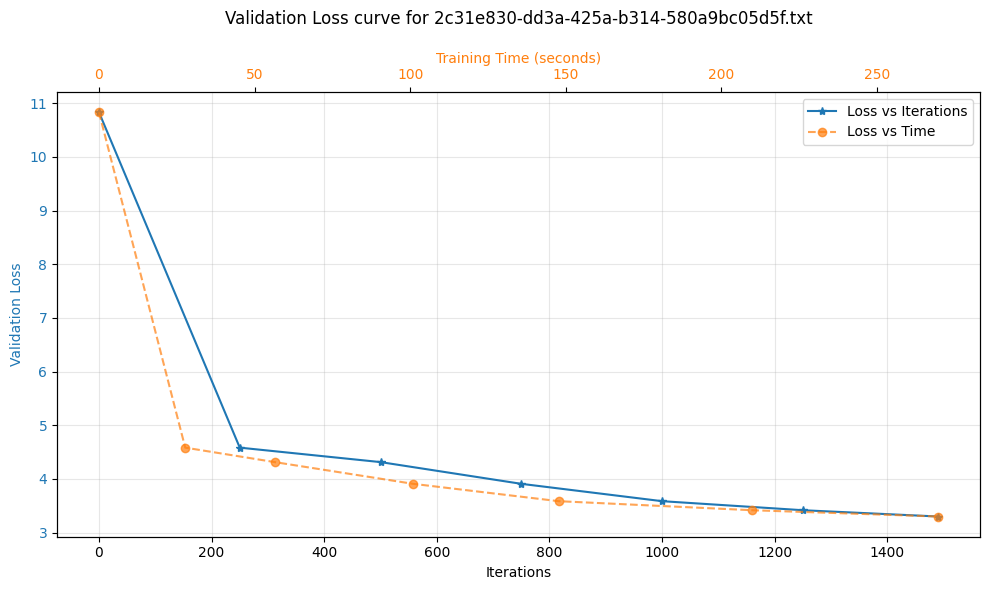

In [7]:
import os
import glob
import re
import matplotlib.pyplot as plt

# Find all log files in the 'logs' folder
log_files = glob.glob('logs/*.txt')
print(f"Found {len(log_files)} log file(s)\n")

for log_file in log_files:
    iterations = []
    val_losses = []
    val_times = []
    peak_memory = "Not found"
    total_time = "Not found"
    final_step_avg = "Not found"
    
    with open(log_file, 'r') as f:
        for line in f:
            if 'val_loss:' in line:
                # Example: step:1000/1490 val_loss:3.5215 train_time:147001ms step_avg:147.00ms
                m = re.search(r'step:(\d+)/\d+.*val_loss:([\d\.]+).*train_time:(\d+)ms', line)
                if m:
                    iterations.append(int(m.group(1)))
                    val_losses.append(float(m.group(2)))
                    val_times.append(int(m.group(3)) / 1000.0) # Convert back to seconds
                    
            if line.startswith('step:'):
                # Update total time and step_avg as we go through steps (will end up with the last one)
                m = re.search(r'train_time:(\d+)ms step_avg:([\d\.]+)ms', line)
                if m:
                    total_time = f"{int(m.group(1)) / 1000.0:.2f}s"
                    final_step_avg = f"{m.group(2)}ms"
                    
            elif 'peak memory allocated' in line:
                peak_memory = line.strip()
    
    print(f"--- {os.path.basename(log_file)} ---")
    print(f"Total Training Time: {total_time}")
    print(f"Final Step Average:  {final_step_avg}")
    print(f"Peak Memory:         {peak_memory}\n")
    
    if not iterations:
        print("No validation loss data found in this log.\n")
        continue
        
    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Validation Loss', color='tab:blue')
    l1 = ax1.plot(iterations, val_losses, '*-', color='tab:blue', label='Loss vs Iterations')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)
    
    # Create a secondary axis for time
    ax2 = ax1.twiny()
    ax2.set_xlabel('Training Time (seconds)', color='tab:orange')
    l2 = ax2.plot(val_times, val_losses, 'o--', color='tab:orange', alpha=0.7, label='Loss vs Time')
    ax2.tick_params(axis='x', labelcolor='tab:orange')
    
    # Display legend
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    
    plt.title(f'Validation Loss curve for {os.path.basename(log_file)}', pad=20)
    plt.tight_layout()
    plt.show()
